<a href="https://colab.research.google.com/github/EswarBarremukala/EswarBarremukala/blob/main/Build_a_model_to_predict_stock_market_performance_using_LSTM_Barremukala_Eswar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# STEP 1: IMPORT LIBRARIES AND LOAD DATASET
# ============================================================

import numpy as np                          # For numerical array operations
import pandas as pd                         # For loading and exploring the CSV
import matplotlib.pyplot as plt             # For plotting predictions vs actuals
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')           # Suppress minor warnings for clean output

# ── Load the training dataset ────────────────────
# Make sure the CSV file is in the same directory as this notebook
dataset_train = pd.read_csv('https://raw.githubusercontent.com/EswarBarremukala/LSTM_DATASET/main/Google_Stock_Price_Train.csv')

# ── Basic Inspection ───────────────────────
print('=' * 55)
print('DATASET SHAPE:', dataset_train.shape)       # (rows, columns)
print('=' * 55)
print('\nFirst 5 rows:')
print(dataset_train.head())

print('\nColumn names:', list(dataset_train.columns))
print('\nData types:')
print(dataset_train.dtypes)

print('\nMissing values per column:')
print(dataset_train.isnull().sum())    # Must all be 0 before proceeding

print('\nBasic Statistics:')
print(dataset_train.describe())

DATASET SHAPE: (1258, 6)

First 5 rows:
       Date    Open    High     Low   Close      Volume
0  1/3/2012  325.25  332.83  324.97  663.59   7,380,500
1  1/4/2012  331.27  333.87  329.08  666.45   5,749,400
2  1/5/2012  329.83  330.75  326.89  657.21   6,590,300
3  1/6/2012  328.34  328.77  323.68  648.24   5,405,900
4  1/9/2012  322.04  322.29  309.46  620.76  11,688,800

Column names: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Data types:
Date       object
Open      float64
High      float64
Low       float64
Close      object
Volume     object
dtype: object

Missing values per column:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Basic Statistics:
              Open         High          Low
count  1258.000000  1258.000000  1258.000000
mean    533.709833   537.880223   529.007409
std     151.904442   153.008811   150.552807
min     279.120000   281.210000   277.220000
25%     404.115000   406.765000   401.765000
50%     537.470000   

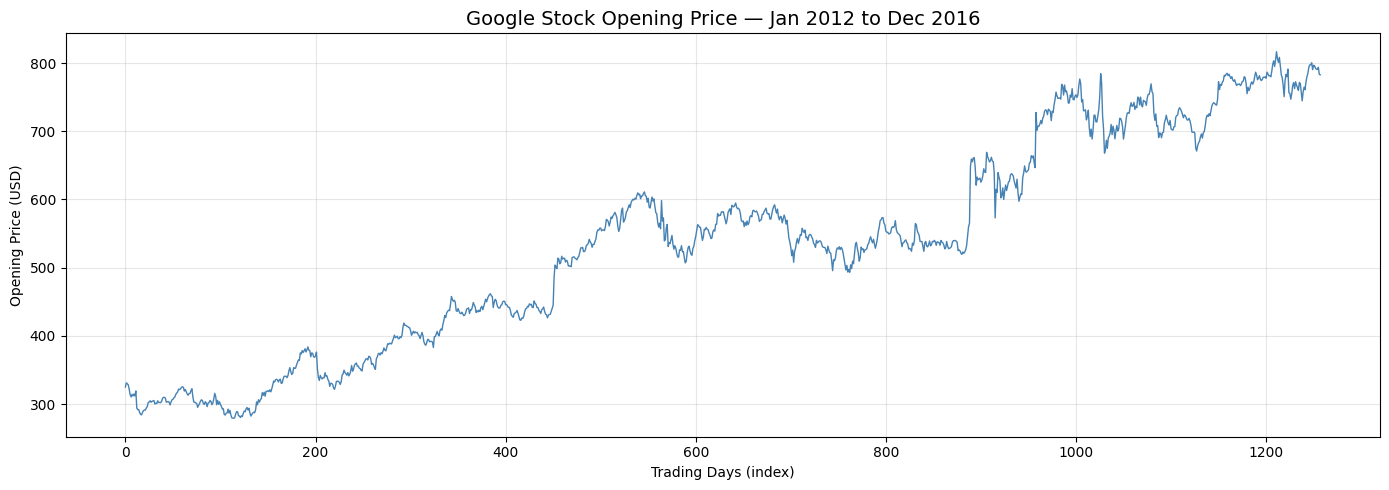


Training period: 1/3/2012  →  12/30/2016
Total trading days: 1258
Min Open Price: $279.12
Max Open Price: $816.68


In [ ]:
# ── Visualise the raw training data ────────────────────────
# Plotting the Open price over the full training period
# This helps us understand the overall trend before modelling

plt.figure(figsize=(14, 5))
plt.plot(dataset_train['Open'].values, color='steelblue', linewidth=1)
plt.title('Google Stock Opening Price — Jan 2012 to Dec 2016', fontsize=14)
plt.xlabel('Trading Days (index)')
plt.ylabel('Opening Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nTraining period: {dataset_train["Date"].iloc[0]}  →  {dataset_train["Date"].iloc[-1]}')
print(f'Total trading days: {len(dataset_train)}')
print(f'Min Open Price: ${dataset_train["Open"].min():.2f}')
print(f'Max Open Price: ${dataset_train["Open"].max():.2f}')

In [ ]:
# ============================================================
# STEP 2: PREPARE DATA — ISOLATE THE TARGET VARIABLE
# ============================================================

# Extract the 'Open' price column (column index 1)
# Using iloc[:, 1:2] to keep 2D shape (n_rows, 1) — required by MinMaxScaler
training_set = dataset_train.iloc[:, 1:2].values

# ── Verify the shape ───────────────────────────────────────
print('Type of training_set :', type(training_set))     # numpy.ndarray
print('Shape of training_set:', training_set.shape)     # Expected: (1257, 1)
print('\nFirst 5 values (Open prices in USD):')
print(training_set[:5])

# ── Confirm 2D shape ───────────────────────────────────────
print('\nNumber of dimensions:', training_set.ndim)     # Must be 2 for MinMaxScaler

Type of training_set : <class 'numpy.ndarray'>
Shape of training_set: (1258, 1)

First 5 values (Open prices in USD):
[[325.25]
 [331.27]
 [329.83]
 [328.34]
 [322.04]]

Number of dimensions: 2


In [ ]:
# ============================================================
# STEP 3: NORMALISE DATA USING MinMaxScaler
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# Initialise MinMaxScaler: scales values to range [0, 1]
sc = MinMaxScaler(feature_range=(0, 1))

# fit_transform on TRAINING data only:
#   fit()      → learns the min and max values from training data
#   transform() → applies the scaling formula to the data
training_set_scaled = sc.fit_transform(training_set)

# ── Verification ───────────────────────────────────────────
print('Original values (first 5):')
print(training_set[:5].flatten())         # e.g. [325.25, 331.27, ...]

print('\nScaled values (first 5):')
print(training_set_scaled[:5].flatten())  # e.g. [0.082, 0.097, ...]

print(f'\nScaled Min: {training_set_scaled.min():.4f}  (should be 0.0)')
print(f'Scaled Max: {training_set_scaled.max():.4f}  (should be 1.0)')
print(f'Scaler learned Min price: ${sc.data_min_[0]:.2f}')
print(f'Scaler learned Max price: ${sc.data_max_[0]:.2f}')

Original values (first 5):
[325.25 331.27 329.83 328.34 322.04]

Scaled values (first 5):
[0.08581368 0.09701243 0.09433366 0.09156187 0.07984225]

Scaled Min: 0.0000  (should be 0.0)
Scaled Max: 1.0000  (should be 1.0)
Scaler learned Min price: $279.12
Scaler learned Max price: $816.68


In [ ]:
# ============================================================
# STEP 4: CREATE TIME-SERIES SEQUENCES (SLIDING WINDOW)
# ============================================================

# Number of previous time steps the LSTM looks back
TIMESTEPS = 60

X_train = []    # Features: 60-day price windows
y_train = []    # Labels:   the price on the next day

# Build sequences: for each position i (starting at day 60),
# take the 60 days before it as input and day i as the label
for i in range(TIMESTEPS, len(training_set_scaled)):
    X_train.append(training_set_scaled[i - TIMESTEPS:i, 0])  # 60 days of prices
    y_train.append(training_set_scaled[i, 0])                 # next day's price

# Convert Python lists to NumPy arrays
X_train = np.array(X_train)   # Shape: (1197, 60)
y_train = np.array(y_train)   # Shape: (1197,)

print('Before reshape:')
print(f'  X_train shape: {X_train.shape}')   # (1197, 60)
print(f'  y_train shape: {y_train.shape}')   # (1197,)

# ── Reshape X_train for LSTM ───────────────────────────────
# LSTM requires 3D input: (samples, timesteps, features)
# We have 1 feature (Open price), so we add a third dimension
X_train = np.reshape(X_train, (X_train.shape[0],   # samples  = 1197
                                X_train.shape[1],   # timesteps = 60
                                1))                 # features  = 1

print('\nAfter reshape (ready for LSTM):')
print(f'  X_train shape: {X_train.shape}')   # (1197, 60, 1)
print(f'  y_train shape: {y_train.shape}')   # (1197,)
print(f'\nTotal training sequences: {X_train.shape[0]}')
print(f'Each sequence covers:     {TIMESTEPS} trading days')

Before reshape:
  X_train shape: (1198, 60)
  y_train shape: (1198,)

After reshape (ready for LSTM):
  X_train shape: (1198, 60, 1)
  y_train shape: (1198,)

Total training sequences: 1198
Each sequence covers:     60 trading days


In [ ]:
# ============================================================
# STEP 5: IMPORT KERAS LIBRARIES FOR LSTM
# ============================================================

# TensorFlow / Keras — deep learning framework
import tensorflow as tf
from keras.models import Sequential        # Linear stack of layers
from keras.layers import Dense             # Fully connected layer
from keras.layers import LSTM              # Long Short-Term Memory layer
from keras.layers import Dropout           # Regularisation layer

# Print version info for reproducibility
print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {tf.keras.__version__}')

# Set random seed for reproducible results
tf.random.set_seed(42)
np.random.seed(42)
print('\nRandom seeds set for reproducibility.')

TensorFlow version : 2.20.0
Keras version      : 3.13.2

Random seeds set for reproducibility.


In [ ]:
# ============================================================
# STEP 6: BUILD THE LSTM MODEL ARCHITECTURE
# ============================================================

# Initialise a Sequential model (layers stacked in order)
regressor = Sequential(name='Google_LSTM_Regressor')

# ── LSTM Layer 1 ───────────────────────────────────────────
# units=50            : 50 LSTM memory cells
# return_sequences=True : output full sequence → feed into next LSTM layer
# input_shape         : (timesteps=60, features=1)
regressor.add(LSTM(units=50,
                   return_sequences=True,
                   input_shape=(X_train.shape[1], 1)))
# Dropout: randomly ignore 20% of neurons to prevent overfitting
regressor.add(Dropout(rate=0.2))

# ── LSTM Layer 2 ───────────────────────────────────────────
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(rate=0.2))

# ── LSTM Layer 3 ───────────────────────────────────────────
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(rate=0.2))

# ── LSTM Layer 4 ───────────────────────────────────────────
# return_sequences=False (default): output only the last timestep
# This feeds into the Dense output layer
regressor.add(LSTM(units=50, return_sequences=False))
regressor.add(Dropout(rate=0.2))

# ── Output Layer ───────────────────────────────────────────
# Dense(1): single neuron → produces one predicted price value
regressor.add(Dense(units=1))

# ── Compile the model ──────────────────────────────────────
# optimizer='adam'            : adaptive learning rate (best for RNNs)
# loss='mean_squared_error'   : standard loss for regression tasks
regressor.compile(optimizer='adam', loss='mean_squared_error')

# ── Model Summary ──────────────────────────────────────────
regressor.summary()

Model: "Google_LSTM_Regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# STEP 7: TRAIN THE LSTM MODEL
# ============================================================

# Train the model on X_train (60-day windows) → y_train (next day price)
# epochs=100    : model sees the full dataset 100 times
# batch_size=32 : update weights after every 32 training samples
# verbose=1     : print progress bar for each epoch

history = regressor.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - loss: 0.0402
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - loss: 0.0061
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - loss: 0.0060
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.0049
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0050
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0050
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - loss: 0.0047
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - loss: 0.0044
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - loss: 0.0042
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 0.0043
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0042
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - loss: 0.0041
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.0037
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0037
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s

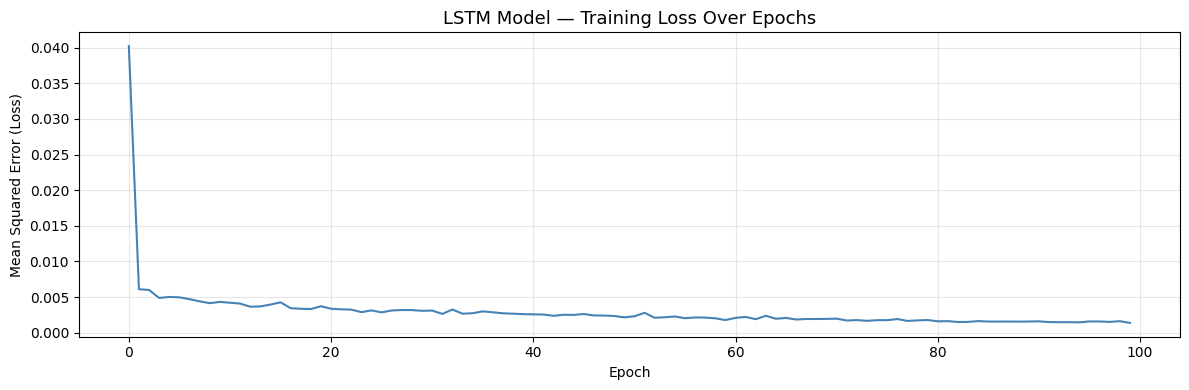

Initial loss  (Epoch 1)  : 0.040201
Final loss    (Epoch 100): 0.001389
Loss reduction           : 96.5%


In [ ]:
# ── Plot Training Loss Curve ───────────────────────────────
# A decreasing loss curve confirms the model is learning correctly
# If loss plateaus early, we might need more epochs or a lower learning rate

plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], color='steelblue', linewidth=1.5)
plt.title('LSTM Model — Training Loss Over Epochs', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Initial loss  (Epoch 1)  : {history.history["loss"][0]:.6f}')
print(f'Final loss    (Epoch 100): {history.history["loss"][-1]:.6f}')
print(f'Loss reduction           : {((history.history["loss"][0] - history.history["loss"][-1]) / history.history["loss"][0]) * 100:.1f}%')

In [ ]:
# ============================================================
# STEP 8: PREPARE TEST DATA & GENERATE PREDICTIONS
# ============================================================

# ── Load test data (January 2017) ───────────────────
dataset_test = pd.read_csv('https://raw.githubusercontent.com/EswarBarremukala/LSTM_DATASET/main/Google_Stock_Price_Test.csv')

# Actual opening prices for Jan 2017 (ground truth for comparison)
real_stock_price = dataset_test.iloc[:, 1:2].values

print('Test dataset shape :', dataset_test.shape)         # (20, 6) — 20 trading days
print('Test period        :', dataset_test['Date'].iloc[0],
      '→', dataset_test['Date'].iloc[-1])
print('\nFirst 5 actual prices (USD):')
print(real_stock_price[:5].flatten())

Test dataset shape : (20, 6)
Test period        : 1/3/2017 → 1/31/2017

First 5 actual prices (USD):
[778.81 788.36 786.08 795.26 806.4 ]


In [ ]:
# ── Build test input sequences ─────────────────────────────

# Combine FULL training Open prices + test Open prices into one series
# This lets us access the 60 days before Jan 2017
dataset_total = pd.concat(
    (dataset_train['Open'], dataset_test['Open']),
    axis=0
)

# Extract the window: [last 60 train days] + [all 20 test days]
# len(dataset_total) - len(dataset_test) - 60 → start index of the 60 days before Jan 2017
inputs = dataset_total[
    len(dataset_total) - len(dataset_test) - 60:
].values

# Reshape to 2D for the scaler: (80, 1)
inputs = inputs.reshape(-1, 1)

# Scale using ALREADY FITTED scaler — transform() only, NOT fit_transform()
# This prevents data leakage from test set into the scaler
inputs = sc.transform(inputs)

print(f'Combined input window size : {inputs.shape}')  # Should be (80, 1)

# Build 60-day sequences for each of the 20 test days
X_test = []
for i in range(60, 80):     # 60 to 80 → gives 20 sequences
    X_test.append(inputs[i - 60:i, 0])     # 60-day window for each prediction

X_test = np.array(X_test)

# Reshape to 3D for LSTM: (samples=20, timesteps=60, features=1)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
print(f'X_test shape (LSTM ready)  : {X_test.shape}')  # (20, 60, 1)

Combined input window size : (80, 1)
X_test shape (LSTM ready)  : (20, 60, 1)


In [ ]:
# ── Generate Predictions ───────────────────────────────────

# Run the trained LSTM on the test sequences
predicted_stock_price_scaled = regressor.predict(X_test)

# Inverse transform: convert normalised predictions back to USD prices
# sc.inverse_transform applies: X = X_norm * (X_max - X_min) + X_min
predicted_stock_price = sc.inverse_transform(predicted_stock_price_scaled)

print('Predicted vs Actual — January 2017 Opening Prices (USD):')
print('=' * 50)
print(f'{"Day":>5}  {"Predicted":>12}  {"Actual":>12}  {"Error":>10}')
print('-' * 50)
for day in range(len(predicted_stock_price)):
    pred  = predicted_stock_price[day][0]
    actual = real_stock_price[day][0]
    error  = abs(pred - actual)
    print(f'{day+1:>5}  ${pred:>11.2f}  ${actual:>11.2f}  ${error:>9.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 790ms/step
Predicted vs Actual — January 2017 Opening Prices (USD):
  Day     Predicted        Actual       Error
--------------------------------------------------
    1  $     783.95  $     778.81  $     5.14
    2  $     781.33  $     788.36  $     7.03
    3  $     781.11  $     786.08  $     4.97
    4  $     782.16  $     795.26  $    13.10
    5  $     785.11  $     806.40  $    21.29
    6  $     790.47  $     807.86  $    17.39
    7  $     795.77  $     805.00  $     9.23
    8  $     798.43  $     807.14  $     8.71
    9  $     799.13  $     807.48  $     8.35
   10  $     798.99  $     807.08  $     8.09
   11  $     798.69  $     805.81  $     7.12
   12  $     798.39  $     805.12  $     6.73
   13  $     798.21  $     806.91  $     8.70
   14  $     798.66  $     807.25  $     8.59
   15  $     799.57  $     822.30  $    22.73
   16  $     803.60  $     829.62  $    26.02
   17  $     809.98  $     837.81  $    27.83
   18  $     817.14  $   

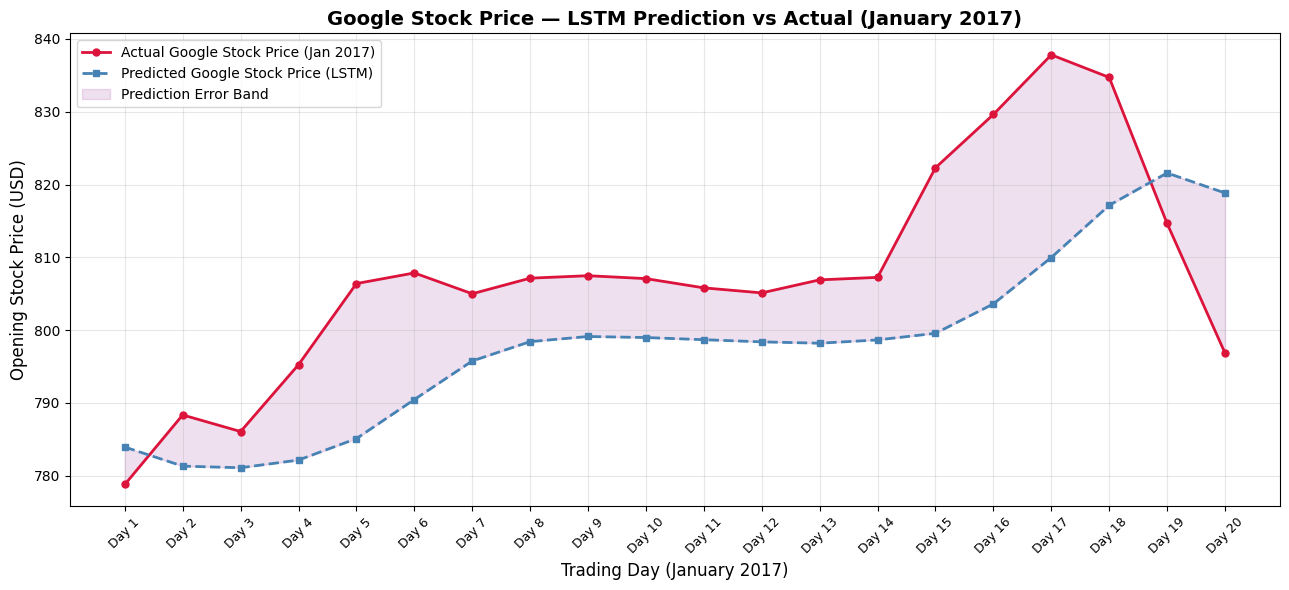

Plot saved as: lstm_prediction_jan2017.png


In [ ]:
# ============================================================
# STEP 9: PLOT PREDICTED VS ACTUAL PRICES — JANUARY 2017
# ============================================================

trading_days = list(range(1, 21))   # Jan 2017 has 20 trading days

plt.figure(figsize=(13, 6))

# ── Actual prices — Red line ──────────────────────────────
plt.plot(trading_days,
         real_stock_price,
         color='crimson',
         linewidth=2,
         marker='o',
         markersize=5,
         label='Actual Google Stock Price (Jan 2017)')

# ── Predicted prices — Blue line ──────────────────────────
plt.plot(trading_days,
         predicted_stock_price,
         color='steelblue',
         linewidth=2,
         marker='s',
         markersize=5,
         linestyle='--',
         label='Predicted Google Stock Price (LSTM)')

# ── Shaded error band between actual and predicted ─────────
plt.fill_between(trading_days,
                 real_stock_price.flatten(),
                 predicted_stock_price.flatten(),
                 alpha=0.12, color='purple',
                 label='Prediction Error Band')

# ── Labels and formatting ──────────────────────────────────
plt.title('Google Stock Price — LSTM Prediction vs Actual (January 2017)',
          fontsize=14, fontweight='bold')
plt.xlabel('Trading Day (January 2017)', fontsize=12)
plt.ylabel('Opening Stock Price (USD)', fontsize=12)
plt.xticks(trading_days, [f'Day {d}' for d in trading_days],
           rotation=45, fontsize=9)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_prediction_jan2017.png', dpi=150, bbox_inches='tight')
plt.show()

print('Plot saved as: lstm_prediction_jan2017.png')

In [ ]:
# ── Model Evaluation Metrics ───────────────────────────────
# Quantify how well the model performed

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Root Mean Squared Error — penalises large errors more heavily
rmse = np.sqrt(mean_squared_error(real_stock_price, predicted_stock_price))

# Mean Absolute Error — average magnitude of error in USD
mae = mean_absolute_error(real_stock_price, predicted_stock_price)

# Mean Absolute Percentage Error — error as % of actual price
mape = np.mean(np.abs((real_stock_price - predicted_stock_price) / real_stock_price)) * 100

# Average actual price for context
avg_actual = np.mean(real_stock_price)

print('=' * 45)
print('         MODEL EVALUATION METRICS')
print('=' * 45)
print(f'  RMSE  (Root Mean Squared Error) : ${rmse:.2f}')
print(f'  MAE   (Mean Absolute Error)     : ${mae:.2f}')
print(f'  MAPE  (Mean Absolute % Error)   : {mape:.2f}%')
print(f'  Avg Actual Price (Jan 2017)     : ${avg_actual:.2f}')
print('=' * 45)
print(f'\n  Accuracy Estimate: ~{100 - mape:.1f}%')
print('  (Lower MAPE = Better prediction)')

         MODEL EVALUATION METRICS
  RMSE  (Root Mean Squared Error) : $14.79
  MAE   (Mean Absolute Error)     : $12.87
  MAPE  (Mean Absolute % Error)   : 1.58%
  Avg Actual Price (Jan 2017)     : $807.53

  Accuracy Estimate: ~98.4%
  (Lower MAPE = Better prediction)


In [ ]:
# ── Optional: Save the trained model ───────────────────────
# Save the model so you don't have to retrain from scratch next time

regressor.save('google_lstm_model.h5')
print('Model saved as: google_lstm_model.h5')

# To load it later:
# from keras.models import load_model
# regressor = load_model('google_lstm_model.h5')

Model saved as: google_lstm_model.h5
